# Feature-Selection Experiment Analysis

Compares 12 experimental conditions: vanilla (AOCC-only feedback) vs 11 single-feature conditions (AOCC + one behavioral metric).

**Goal**: Identify which behavioral metrics, when shown as feedback, improve the quality of LLM-designed optimization algorithms.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

RESULTS_DIR = Path("../results")
N_INSTANCES = 10
N_SEEDS = 5
BUDGET = 100  # candidates per condition

FEATURE_CATEGORIES = {
    "Exploration & Diversity": [
        "avg_nearest_neighbor_distance",
        "dispersion",
        "avg_exploration_pct",
    ],
    "Exploitation & Intensification": [
        "avg_distance_to_best",
        "intensification_ratio",
        "avg_exploitation_pct",
    ],
    "Convergence Progress": [
        "average_convergence_rate",
        "avg_improvement",
        "success_rate",
    ],
    "Stagnation & Reliability": [
        "longest_no_improvement_streak",
        "last_improvement_fraction",
    ],
}

ALL_FEATURES = [f for feats in FEATURE_CATEGORIES.values() for f in feats]
CONDITIONS = ["vanilla"] + ALL_FEATURES

# Short display names for plots
SHORT_NAMES = {
    "vanilla": "vanilla",
    "avg_nearest_neighbor_distance": "nn_dist",
    "dispersion": "dispersion",
    "avg_exploration_pct": "explore_%",
    "avg_distance_to_best": "dist_best",
    "intensification_ratio": "intens_ratio",
    "avg_exploitation_pct": "exploit_%",
    "average_convergence_rate": "conv_rate",
    "avg_improvement": "avg_improv",
    "success_rate": "success_%",
    "longest_no_improvement_streak": "no_improv",
    "last_improvement_fraction": "last_improv",
}

print(f"Conditions: {len(CONDITIONS)}")
print(f"Features: {len(ALL_FEATURES)}")

Conditions: 12
Features: 11


## 1. Data Loading

In [2]:
def parse_fitness(val):
    """Convert fitness to float — handles string '-inf' from failed candidates."""
    try:
        return float(val)
    except (TypeError, ValueError):
        return float("-inf")


def load_condition(condition_name):
    """Load all candidates from a condition's log.jsonl."""
    run_dir = RESULTS_DIR / condition_name
    log_files = sorted(run_dir.glob("run-*/log.jsonl"))
    if not log_files:
        raise FileNotFoundError(f"No log.jsonl found for {condition_name}")
    log_file = log_files[0]
    
    candidates = []
    with open(log_file) as f:
        for i, line in enumerate(f):
            entry = json.loads(line)
            fitness = parse_fitness(entry["fitness"])
            failed = fitness == float("-inf")
            
            row = {
                "condition": condition_name,
                "evaluation": i,
                "fitness": fitness,
                "failed": failed,
                "name": entry["name"],
                "generation": entry["generation"],
                "parent_ids": entry.get("parent_ids", []),
            }
            
            aucs = entry.get("metadata", {}).get("aucs", [])
            row["aucs"] = aucs
            
            if not failed and len(aucs) > 0:
                row["auc_mean"] = np.mean(aucs)
                row["auc_std"] = np.std(aucs)
            else:
                row["auc_mean"] = np.nan
                row["auc_std"] = np.nan
            
            # Per-instance means (average over 5 seeds per instance)
            if not failed and len(aucs) == N_INSTANCES * N_SEEDS:
                aucs_arr = np.array(aucs).reshape(N_INSTANCES, N_SEEDS)
                for inst in range(N_INSTANCES):
                    row[f"instance_{inst}"] = aucs_arr[inst].mean()
            else:
                for inst in range(N_INSTANCES):
                    row[f"instance_{inst}"] = np.nan
            
            # Behavioral features
            bf = entry.get("metadata", {}).get("behavioral_features", {})
            for feat in ALL_FEATURES:
                row[feat] = bf.get(feat) if not failed else np.nan
            
            candidates.append(row)
    
    return candidates


# Load all conditions
all_rows = []
for cond in CONDITIONS:
    try:
        rows = load_condition(cond)
        all_rows.extend(rows)
        n_failed = sum(1 for r in rows if r["failed"])
        print(f"{cond}: {len(rows)} candidates ({len(rows) - n_failed} valid, {n_failed} failed)")
    except FileNotFoundError as e:
        print(f"WARNING: {e}")

df = pd.DataFrame(all_rows)
df_valid = df[~df["failed"]].copy()

print(f"\nTotal: {len(df)} candidates ({len(df_valid)} valid, {len(df) - len(df_valid)} failed)")
print(f"Overall failure rate: {(len(df) - len(df_valid)) / len(df) * 100:.1f}%")

vanilla: 100 candidates (33 valid, 67 failed)
avg_nearest_neighbor_distance: 100 candidates (14 valid, 86 failed)
dispersion: 100 candidates (26 valid, 74 failed)
avg_exploration_pct: 100 candidates (45 valid, 55 failed)
avg_distance_to_best: 100 candidates (6 valid, 94 failed)
intensification_ratio: 100 candidates (6 valid, 94 failed)
avg_exploitation_pct: 100 candidates (15 valid, 85 failed)
average_convergence_rate: 100 candidates (50 valid, 50 failed)
avg_improvement: 100 candidates (37 valid, 63 failed)
success_rate: 100 candidates (1 valid, 99 failed)
longest_no_improvement_streak: 100 candidates (32 valid, 68 failed)
last_improvement_fraction: 100 candidates (13 valid, 87 failed)

Total: 1200 candidates (278 valid, 922 failed)
Overall failure rate: 76.8%


In [3]:
# Compute best-so-far fitness per condition
# -inf doesn't affect cummax (it stays at whatever valid max was seen)
df["best_so_far"] = df.groupby("condition")["fitness"].cummax()

# Summary: final best AOCC per condition
final_best = df.groupby("condition")["best_so_far"].last().reindex(CONDITIONS)
print("Final best AOCC per condition:")
print(final_best.to_string())

# Failure rate summary
print("\nFailure rates:")
for cond in CONDITIONS:
    cond_df = df[df["condition"] == cond]
    n_fail = cond_df["failed"].sum()
    print(f"  {SHORT_NAMES[cond]:>15s}: {n_fail:3d}/100 failed ({n_fail}%)")

Final best AOCC per condition:
condition
vanilla                          0.416028
avg_nearest_neighbor_distance    0.340315
dispersion                       0.476221
avg_exploration_pct              0.428991
avg_distance_to_best             0.216589
intensification_ratio            0.218160
avg_exploitation_pct             0.660403
average_convergence_rate         0.343754
avg_improvement                  0.705171
success_rate                     0.284640
longest_no_improvement_streak    0.580867
last_improvement_fraction        0.517843

Failure rates:
          vanilla:  67/100 failed (67%)
          nn_dist:  86/100 failed (86%)
       dispersion:  74/100 failed (74%)
        explore_%:  55/100 failed (55%)
        dist_best:  94/100 failed (94%)
     intens_ratio:  94/100 failed (94%)
        exploit_%:  85/100 failed (85%)
        conv_rate:  50/100 failed (50%)
       avg_improv:  63/100 failed (63%)
        success_%:  99/100 failed (99%)
        no_improv:  68/100 failed (68%)

## 2. Best-so-far Convergence Curves

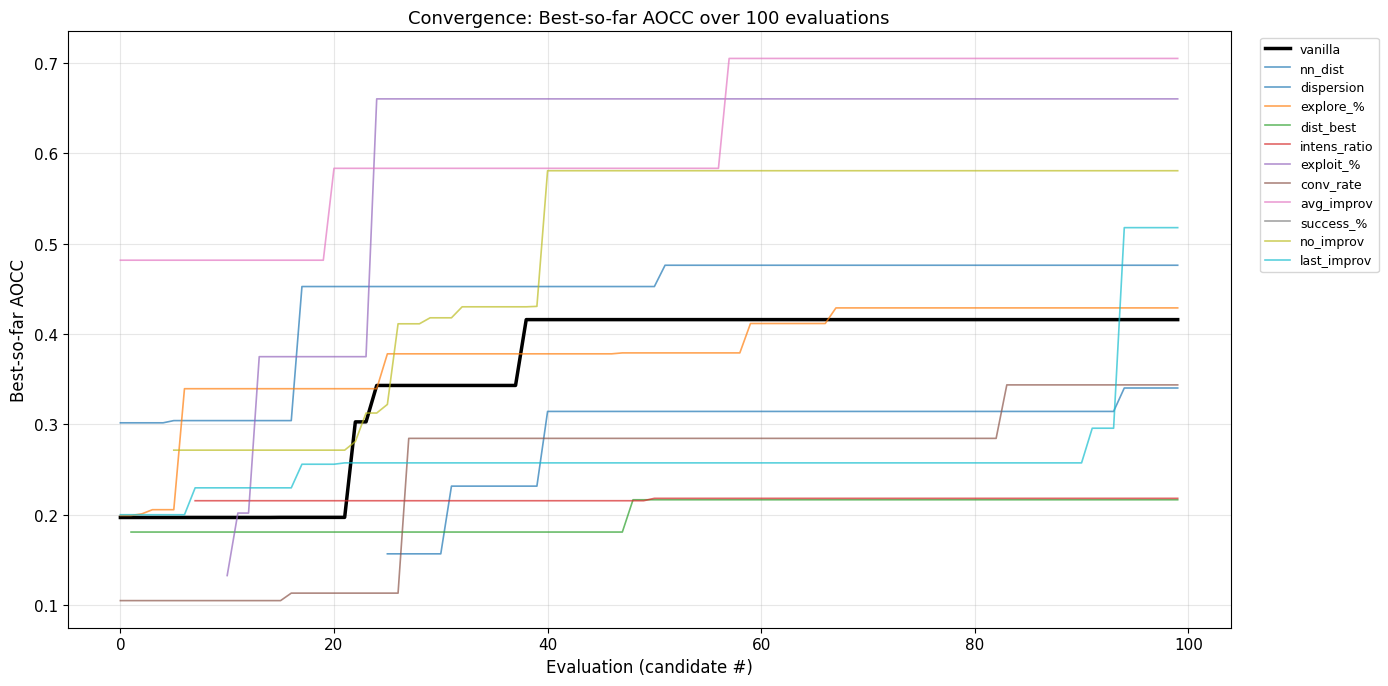

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

cmap = plt.cm.tab10
colors = {"vanilla": "black"}
for i, feat in enumerate(ALL_FEATURES):
    colors[feat] = cmap(i / len(ALL_FEATURES))

for cond in CONDITIONS:
    subset = df[df["condition"] == cond].sort_values("evaluation")
    # Replace -inf with NaN so matplotlib skips those points
    bsf = subset["best_so_far"].replace(-np.inf, np.nan)
    lw = 2.5 if cond == "vanilla" else 1.2
    alpha = 1.0 if cond == "vanilla" else 0.7
    ax.plot(
        subset["evaluation"], bsf,
        label=SHORT_NAMES[cond], color=colors[cond],
        linewidth=lw, alpha=alpha,
    )

ax.set_xlabel("Evaluation (candidate #)")
ax.set_ylabel("Best-so-far AOCC")
ax.set_title("Convergence: Best-so-far AOCC over 100 evaluations")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

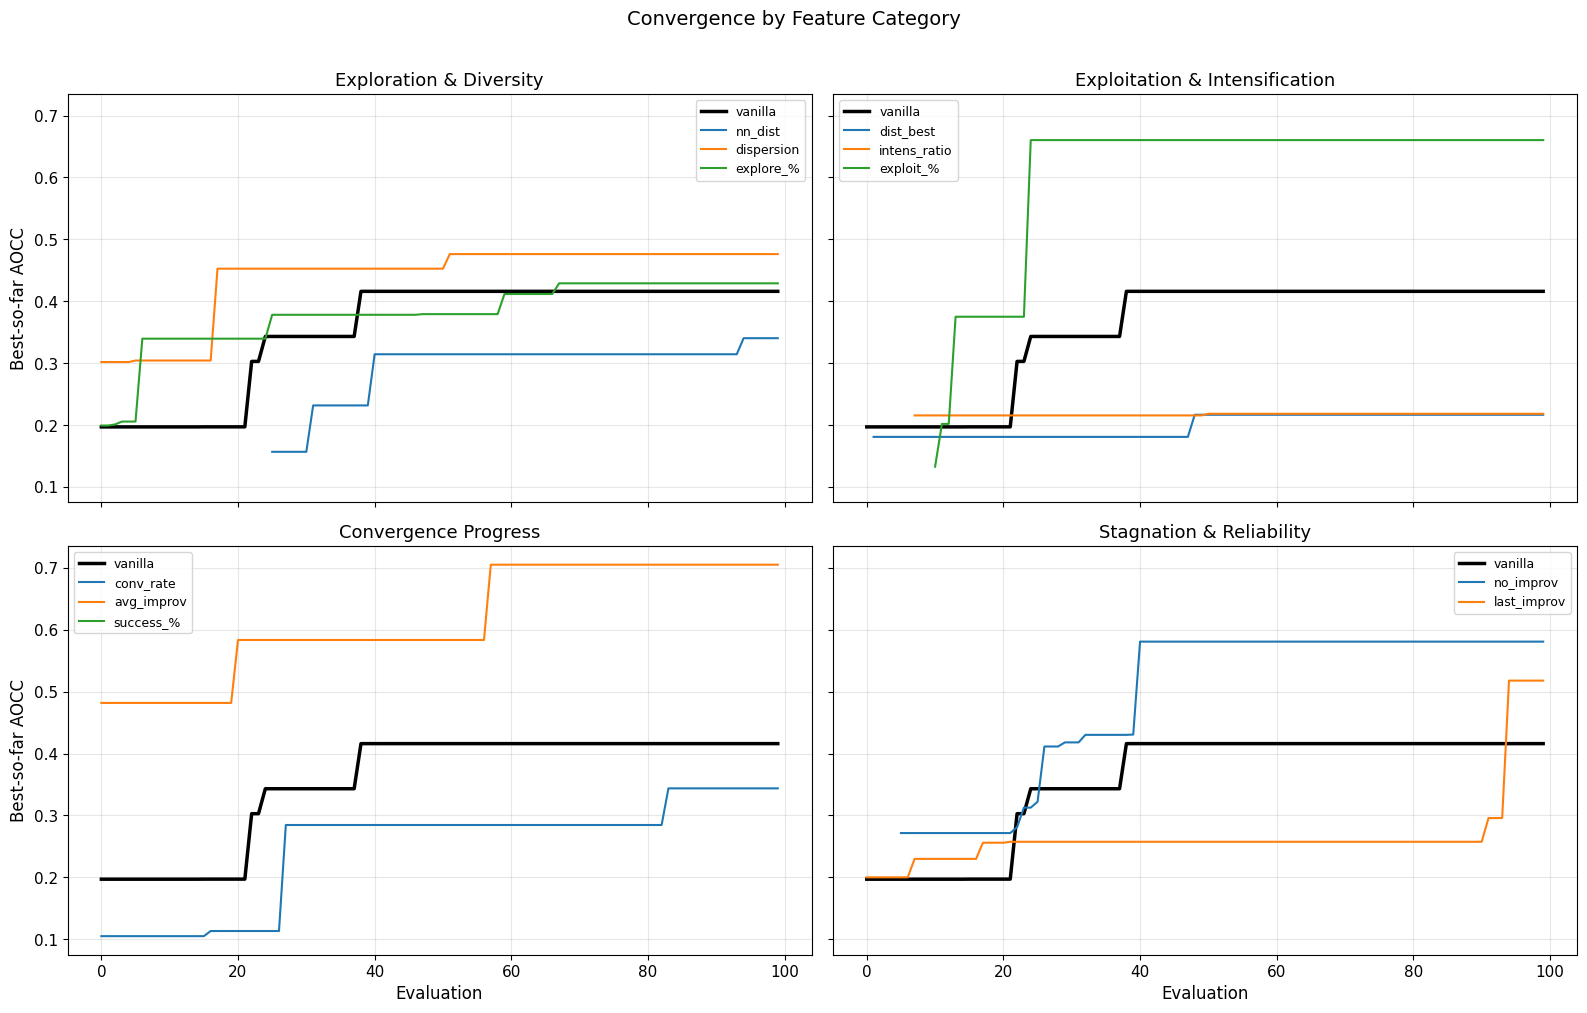

In [5]:
# Grouped by category
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

for ax, (cat_name, features) in zip(axes.flat, FEATURE_CATEGORIES.items()):
    v = df[df["condition"] == "vanilla"].sort_values("evaluation")
    bsf_v = v["best_so_far"].replace(-np.inf, np.nan)
    ax.plot(v["evaluation"], bsf_v, label="vanilla", color="black", linewidth=2.5)
    
    for i, feat in enumerate(features):
        subset = df[df["condition"] == feat].sort_values("evaluation")
        bsf = subset["best_so_far"].replace(-np.inf, np.nan)
        ax.plot(subset["evaluation"], bsf, label=SHORT_NAMES[feat], linewidth=1.5)
    
    ax.set_title(cat_name)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1, 0].set_xlabel("Evaluation")
axes[1, 1].set_xlabel("Evaluation")
axes[0, 0].set_ylabel("Best-so-far AOCC")
axes[1, 0].set_ylabel("Best-so-far AOCC")
fig.suptitle("Convergence by Feature Category", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Final Performance Comparison

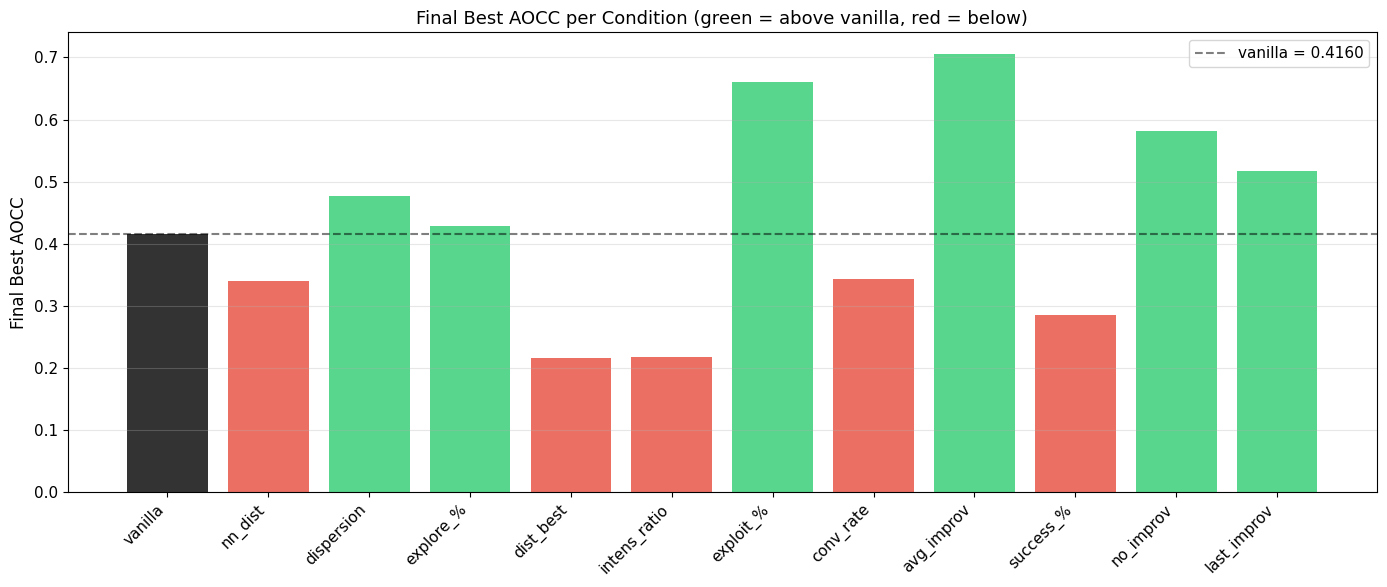

                               final_best_aocc  delta_vs_vanilla  pct_change
condition                                                                   
avg_improvement                         0.7052            0.2891     69.5007
avg_exploitation_pct                    0.6604            0.2444     58.7400
longest_no_improvement_streak           0.5809            0.1648     39.6220
last_improvement_fraction               0.5178            0.1018     24.4731
dispersion                              0.4762            0.0602     14.4685
avg_exploration_pct                     0.4290            0.0130      3.1158
vanilla                                 0.4160            0.0000      0.0000
average_convergence_rate                0.3438           -0.0723    -17.3724
avg_nearest_neighbor_distance           0.3403           -0.0757    -18.1991
success_rate                            0.2846           -0.1314    -31.5815
intensification_ratio                   0.2182           -0.1979    -47.5612

In [6]:
# Bar chart of final best AOCC
vanilla_final = final_best["vanilla"]

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(CONDITIONS))
bar_colors = ["black" if c == "vanilla" else
              ("#2ecc71" if final_best[c] > vanilla_final else "#e74c3c")
              for c in CONDITIONS]

bars = ax.bar(x, [final_best[c] for c in CONDITIONS], color=bar_colors, alpha=0.8)
ax.axhline(vanilla_final, color="black", linestyle="--", alpha=0.5, label=f"vanilla = {vanilla_final:.4f}")

ax.set_xticks(x)
ax.set_xticklabels([SHORT_NAMES[c] for c in CONDITIONS], rotation=45, ha="right")
ax.set_ylabel("Final Best AOCC")
ax.set_title("Final Best AOCC per Condition (green = above vanilla, red = below)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    "condition": CONDITIONS,
    "final_best_aocc": [final_best[c] for c in CONDITIONS],
    "delta_vs_vanilla": [final_best[c] - vanilla_final for c in CONDITIONS],
    "pct_change": [(final_best[c] - vanilla_final) / vanilla_final * 100 for c in CONDITIONS],
}).set_index("condition")
summary = summary.sort_values("final_best_aocc", ascending=False)
print(summary.to_string(float_format="{:.4f}".format))

/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_99774/1410198995.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels,


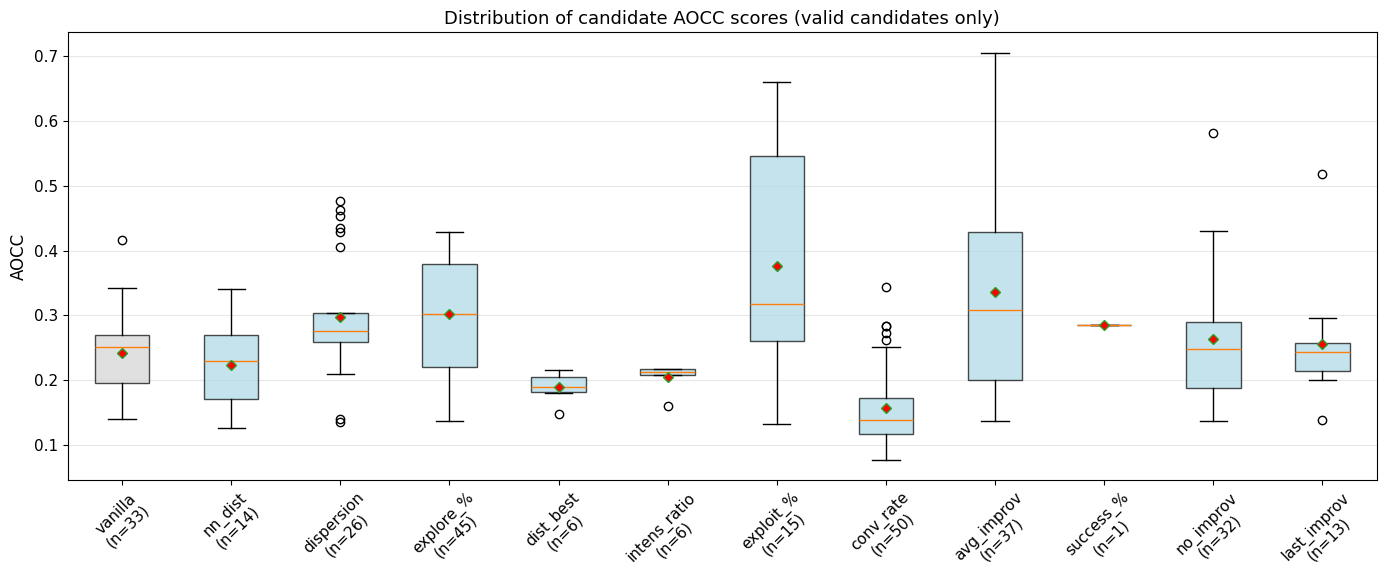

In [7]:
# Distribution of per-candidate AOCC (valid candidates only)
fig, ax = plt.subplots(figsize=(14, 6))

data_for_box = []
labels = []
for c in CONDITIONS:
    vals = df_valid[df_valid["condition"] == c]["fitness"].values
    data_for_box.append(vals if len(vals) > 0 else [np.nan])
    n = len(vals)
    labels.append(f"{SHORT_NAMES[c]}\n(n={n})")

bp = ax.boxplot(data_for_box, labels=labels,
                patch_artist=True, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "red", "markersize": 5})

for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("lightgray" if CONDITIONS[i] == "vanilla" else "lightblue")
    patch.set_alpha(0.7)

ax.set_ylabel("AOCC")
ax.set_title("Distribution of candidate AOCC scores (valid candidates only)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. Statistical Testing

For each condition vs vanilla:
- **Mann-Whitney U** on candidate AOCC distributions (100 vs 100 candidates)
- **Wilcoxon signed-rank** on the 50 per-instance AUC scores of each condition's best algorithm vs vanilla's best
- **Cliff's delta** effect size
- **Bootstrap 95% CI** for mean AOCC difference

In [8]:
def cliffs_delta(x, y):
    """Compute Cliff's delta effect size."""
    n_x, n_y = len(x), len(y)
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


def cliffs_delta_label(d):
    """Interpret Cliff's delta magnitude."""
    d = abs(d)
    if d < 0.147:
        return "negligible"
    elif d < 0.33:
        return "small"
    elif d < 0.474:
        return "medium"
    else:
        return "large"


def bootstrap_ci(x, y, n_boot=10000, ci=0.95):
    """Bootstrap CI for mean(x) - mean(y)."""
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(n_boot):
        bx = rng.choice(x, size=len(x), replace=True)
        by = rng.choice(y, size=len(y), replace=True)
        diffs.append(bx.mean() - by.mean())
    diffs = np.array(diffs)
    lo = np.percentile(diffs, (1 - ci) / 2 * 100)
    hi = np.percentile(diffs, (1 + ci) / 2 * 100)
    return lo, hi

In [9]:
# Test 1: Mann-Whitney U on candidate AOCC distributions
# Only compare conditions with enough valid candidates
MIN_SAMPLES = 5

vanilla_fitness = df_valid[df_valid["condition"] == "vanilla"]["fitness"].values
print(f"Vanilla: {len(vanilla_fitness)} valid candidates\n")

if len(vanilla_fitness) < MIN_SAMPLES:
    print("WARNING: Vanilla has too few valid candidates for statistical testing!")

mw_results = []
for feat in ALL_FEATURES:
    feat_fitness = df_valid[df_valid["condition"] == feat]["fitness"].values
    
    if len(feat_fitness) < MIN_SAMPLES:
        print(f"SKIP {SHORT_NAMES[feat]}: only {len(feat_fitness)} valid candidates (need >= {MIN_SAMPLES})")
        continue
    
    stat, p = stats.mannwhitneyu(feat_fitness, vanilla_fitness, alternative="two-sided")
    d = cliffs_delta(feat_fitness, vanilla_fitness)
    ci_lo, ci_hi = bootstrap_ci(feat_fitness, vanilla_fitness)
    
    mw_results.append({
        "condition": feat,
        "n_valid": len(feat_fitness),
        "mean_aocc": feat_fitness.mean(),
        "vanilla_mean": vanilla_fitness.mean(),
        "mean_diff": feat_fitness.mean() - vanilla_fitness.mean(),
        "U_statistic": stat,
        "p_value": p,
        "cliffs_delta": d,
        "effect_size": cliffs_delta_label(d),
        "ci_95_lo": ci_lo,
        "ci_95_hi": ci_hi,
    })

if mw_results:
    mw_df = pd.DataFrame(mw_results).set_index("condition").sort_values("mean_diff", ascending=False)
    print("\nMann-Whitney U test: each condition's valid candidates vs vanilla's valid candidates")
    print("=" * 110)
    print(mw_df[["n_valid", "mean_diff", "p_value", "cliffs_delta", "effect_size", "ci_95_lo", "ci_95_hi"]].to_string(
        float_format="{:.4f}".format
    ))
else:
    print("\nNo conditions had enough valid candidates for testing.")

Vanilla: 33 valid candidates

SKIP success_%: only 1 valid candidates (need >= 5)

Mann-Whitney U test: each condition's valid candidates vs vanilla's valid candidates
                               n_valid  mean_diff  p_value  cliffs_delta effect_size  ci_95_lo  ci_95_hi
condition                                                                                               
avg_exploitation_pct                15     0.1344   0.0076        0.4869       large    0.0451    0.2284
avg_improvement                     37     0.0942   0.0059        0.3841      medium    0.0451    0.1449
avg_exploration_pct                 45     0.0603   0.0028        0.3993      medium    0.0287    0.0929
dispersion                          26     0.0557   0.0067        0.4149      medium    0.0167    0.0959
longest_no_improvement_streak       32     0.0225   0.7779        0.0417  negligible   -0.0135    0.0615
last_improvement_fraction           13     0.0138   0.8262        0.0443  negligible   -0.0304   

In [10]:
# Test 2: Wilcoxon signed-rank on 50 per-instance AUC scores of best algorithm
# (paired comparison: same instance+seed evaluated by both algorithms)

def get_best_aucs(condition):
    """Get the 50 AUC scores of the best valid candidate in a condition."""
    cond_df = df_valid[df_valid["condition"] == condition]
    if len(cond_df) == 0:
        return np.array([]), "N/A"
    best_row = cond_df.sort_values("fitness", ascending=False).iloc[0]
    aucs = np.array(best_row["aucs"])
    return aucs, best_row["name"]

vanilla_aucs, vanilla_best_name = get_best_aucs("vanilla")
if len(vanilla_aucs) == N_INSTANCES * N_SEEDS:
    print(f"Vanilla best algorithm: {vanilla_best_name} (mean AOCC: {vanilla_aucs.mean():.4f})\n")
else:
    print(f"WARNING: Vanilla best has {len(vanilla_aucs)} AUCs (expected {N_INSTANCES * N_SEEDS})\n")

wilcoxon_results = []
for feat in ALL_FEATURES:
    feat_aucs, feat_best_name = get_best_aucs(feat)
    
    if len(feat_aucs) != N_INSTANCES * N_SEEDS or len(vanilla_aucs) != N_INSTANCES * N_SEEDS:
        print(f"SKIP {SHORT_NAMES[feat]}: insufficient AUC data ({len(feat_aucs)} scores)")
        continue
    
    try:
        stat, p = stats.wilcoxon(feat_aucs, vanilla_aucs, alternative="two-sided")
    except ValueError:
        stat, p = np.nan, np.nan
    
    d = cliffs_delta(feat_aucs, vanilla_aucs)
    ci_lo, ci_hi = bootstrap_ci(feat_aucs, vanilla_aucs)
    
    wilcoxon_results.append({
        "condition": feat,
        "best_algo": feat_best_name,
        "mean_aocc": feat_aucs.mean(),
        "mean_diff": feat_aucs.mean() - vanilla_aucs.mean(),
        "W_statistic": stat,
        "p_value": p,
        "cliffs_delta": d,
        "effect_size": cliffs_delta_label(d),
        "ci_95_lo": ci_lo,
        "ci_95_hi": ci_hi,
    })

if wilcoxon_results:
    wil_df = pd.DataFrame(wilcoxon_results).set_index("condition").sort_values("mean_diff", ascending=False)
    print("\nWilcoxon signed-rank: best algorithm's 50 AUC scores (paired by instance+seed)")
    print("=" * 110)
    print(wil_df[["best_algo", "mean_diff", "p_value", "cliffs_delta", "effect_size", "ci_95_lo", "ci_95_hi"]].to_string(
        float_format="{:.4f}".format
    ))
else:
    print("\nNo conditions had sufficient data for paired testing.")

Vanilla best algorithm: AdaptiveDirectionalSamplingWithCovarianceAndLocalOptimization (mean AOCC: 0.4160)


Wilcoxon signed-rank: best algorithm's 50 AUC scores (paired by instance+seed)
                                                            best_algo  mean_diff  p_value  cliffs_delta effect_size  ci_95_lo  ci_95_hi
condition                                                                                                                              
avg_improvement                    DynamicExploreAdaptivePerturbation     0.2891   0.0000        0.6080       large    0.1852    0.3886
avg_exploitation_pct              AdaptiveHybridDifferentialEvolution     0.2444   0.0000        0.5528       large    0.1522    0.3340
longest_no_improvement_streak           HybridPhaseDiversityOptimizer     0.1648   0.0000        0.3192       small    0.0554    0.2755
last_improvement_fraction      AdaptiveMomentumWithDynamicExploration     0.1018   0.0003        0.2600       small    0.0032    0.20

## 5. Per-Instance Analysis

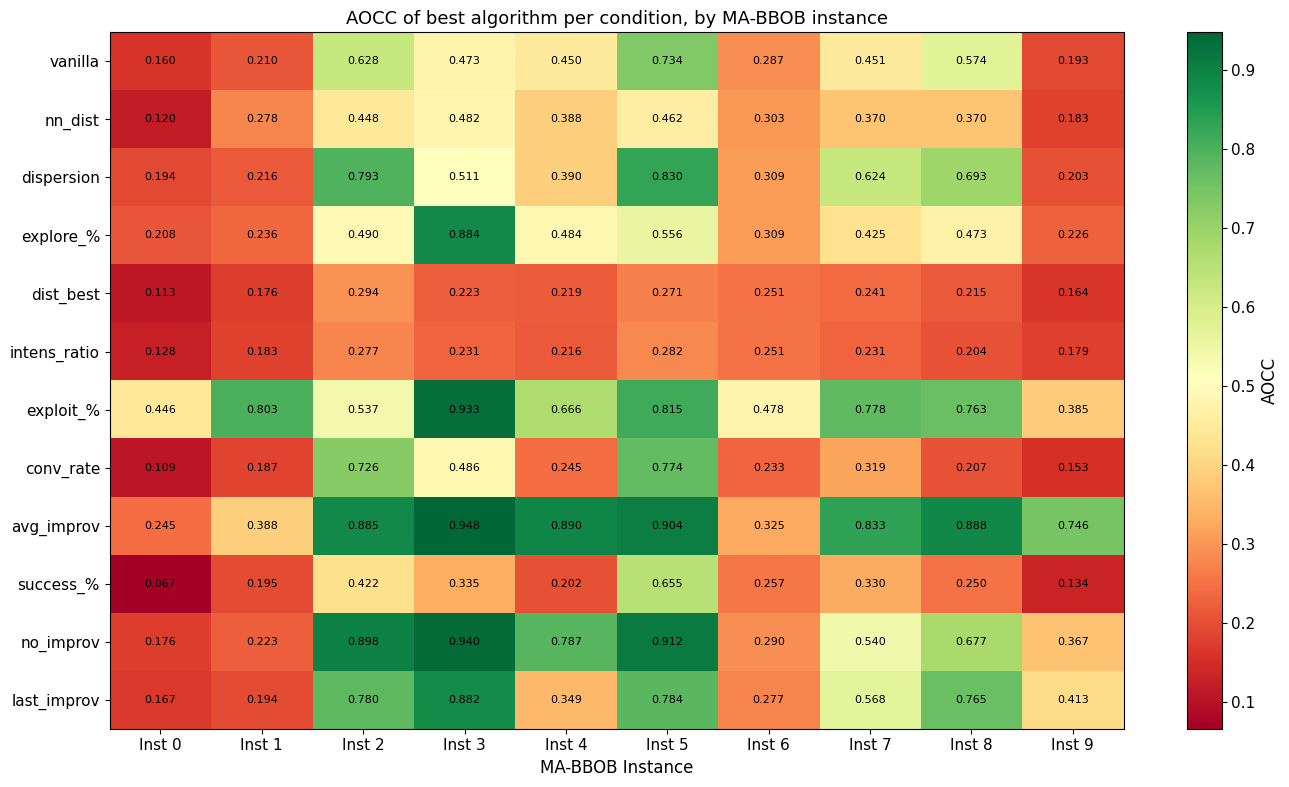

In [11]:
# Heatmap: AOCC of each condition's best algorithm, broken down by instance
instance_cols = [f"instance_{i}" for i in range(N_INSTANCES)]

heatmap_data = []
for cond in CONDITIONS:
    cond_valid = df_valid[df_valid["condition"] == cond]
    row = {"condition": cond}
    if len(cond_valid) > 0:
        best_row = cond_valid.sort_values("fitness", ascending=False).iloc[0]
        for col in instance_cols:
            row[col] = best_row.get(col, np.nan)
    else:
        for col in instance_cols:
            row[col] = np.nan
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data).set_index("condition").reindex(CONDITIONS)
hm_df.columns = [f"Inst {i}" for i in range(N_INSTANCES)]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(hm_df.values, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(N_INSTANCES))
ax.set_xticklabels(hm_df.columns)
ax.set_yticks(range(len(CONDITIONS)))
ax.set_yticklabels([SHORT_NAMES[c] for c in CONDITIONS])

for i in range(len(CONDITIONS)):
    for j in range(N_INSTANCES):
        val = hm_df.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="AOCC")
ax.set_title("AOCC of best algorithm per condition, by MA-BBOB instance")
ax.set_xlabel("MA-BBOB Instance")
plt.tight_layout()
plt.show()

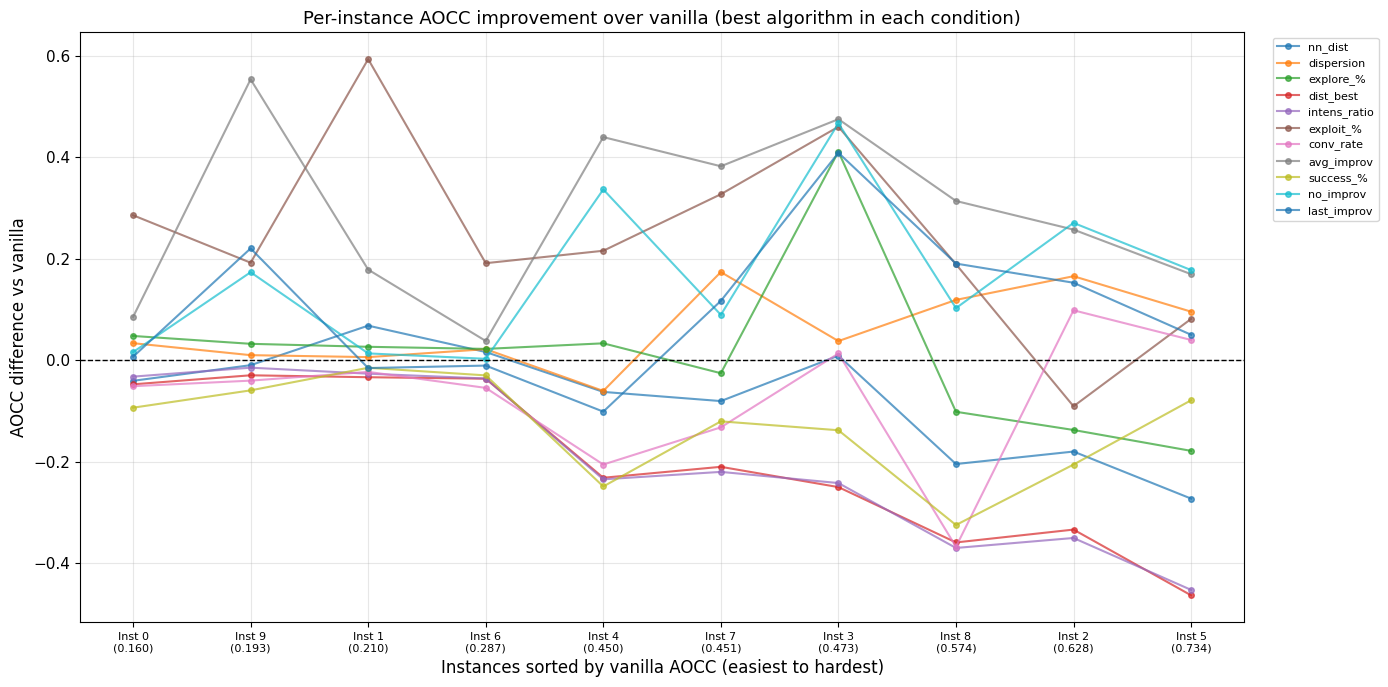

In [12]:
# Instance difficulty: rank by vanilla performance, check if feedback helps more on hard instances
vanilla_instance_scores = hm_df.loc["vanilla"].values

if np.all(np.isnan(vanilla_instance_scores)):
    print("Cannot compute instance difficulty — vanilla has no valid per-instance scores")
else:
    # Sort by vanilla score (easy to hard)
    valid_mask = ~np.isnan(vanilla_instance_scores)
    instance_ranking = np.argsort(vanilla_instance_scores)  # easy to hard

    fig, ax = plt.subplots(figsize=(14, 7))

    for cond in ALL_FEATURES:
        cond_scores = hm_df.loc[cond].values
        if np.all(np.isnan(cond_scores)):
            continue
        diffs = cond_scores - vanilla_instance_scores
        ax.plot(range(N_INSTANCES), diffs[instance_ranking],
                label=SHORT_NAMES[cond], marker="o", markersize=4, alpha=0.7)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(range(N_INSTANCES))
    ax.set_xticklabels([f"Inst {instance_ranking[i]}\n({vanilla_instance_scores[instance_ranking[i]]:.3f})"
                         for i in range(N_INSTANCES)], fontsize=8)
    ax.set_xlabel("Instances sorted by vanilla AOCC (easiest to hardest)")
    ax.set_ylabel("AOCC difference vs vanilla")
    ax.set_title("Per-instance AOCC improvement over vanilla (best algorithm in each condition)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
# Per-instance statistical test: for each instance, compare 5 seed-level AUCs
# of each condition's best algorithm vs vanilla's best

if len(vanilla_aucs) != N_INSTANCES * N_SEEDS:
    print(f"Cannot run per-instance test — vanilla has {len(vanilla_aucs)} AUCs (expected {N_INSTANCES * N_SEEDS})")
else:
    vanilla_aucs_2d = np.array(vanilla_aucs).reshape(N_INSTANCES, N_SEEDS)

    inst_test_results = []
    for feat in ALL_FEATURES:
        feat_aucs_flat, _ = get_best_aucs(feat)
        if len(feat_aucs_flat) != N_INSTANCES * N_SEEDS:
            continue
        feat_aucs_2d = feat_aucs_flat.reshape(N_INSTANCES, N_SEEDS)
        
        wins = 0
        for inst in range(N_INSTANCES):
            if feat_aucs_2d[inst].mean() > vanilla_aucs_2d[inst].mean():
                wins += 1
        
        inst_test_results.append({
            "condition": feat,
            "instances_better": wins,
            "instances_worse": N_INSTANCES - wins,
        })

    if inst_test_results:
        inst_df = pd.DataFrame(inst_test_results).set_index("condition").sort_values("instances_better", ascending=False)
        print("Per-instance wins: how many of the 10 instances does each condition's best algo beat vanilla's best?")
        print(inst_df.to_string())
    else:
        print("No conditions had sufficient AUC data for per-instance comparison.")

Per-instance wins: how many of the 10 instances does each condition's best algo beat vanilla's best?
                               instances_better  instances_worse
condition                                                       
avg_improvement                              10                0
longest_no_improvement_streak                10                0
dispersion                                    9                1
avg_exploitation_pct                          9                1
last_improvement_fraction                     7                3
avg_exploration_pct                           6                4
avg_nearest_neighbor_distance                 3                7
average_convergence_rate                      3                7
avg_distance_to_best                          0               10
intensification_ratio                         0               10
success_rate                                  0               10


## 6. Behavioral Metric Evolution

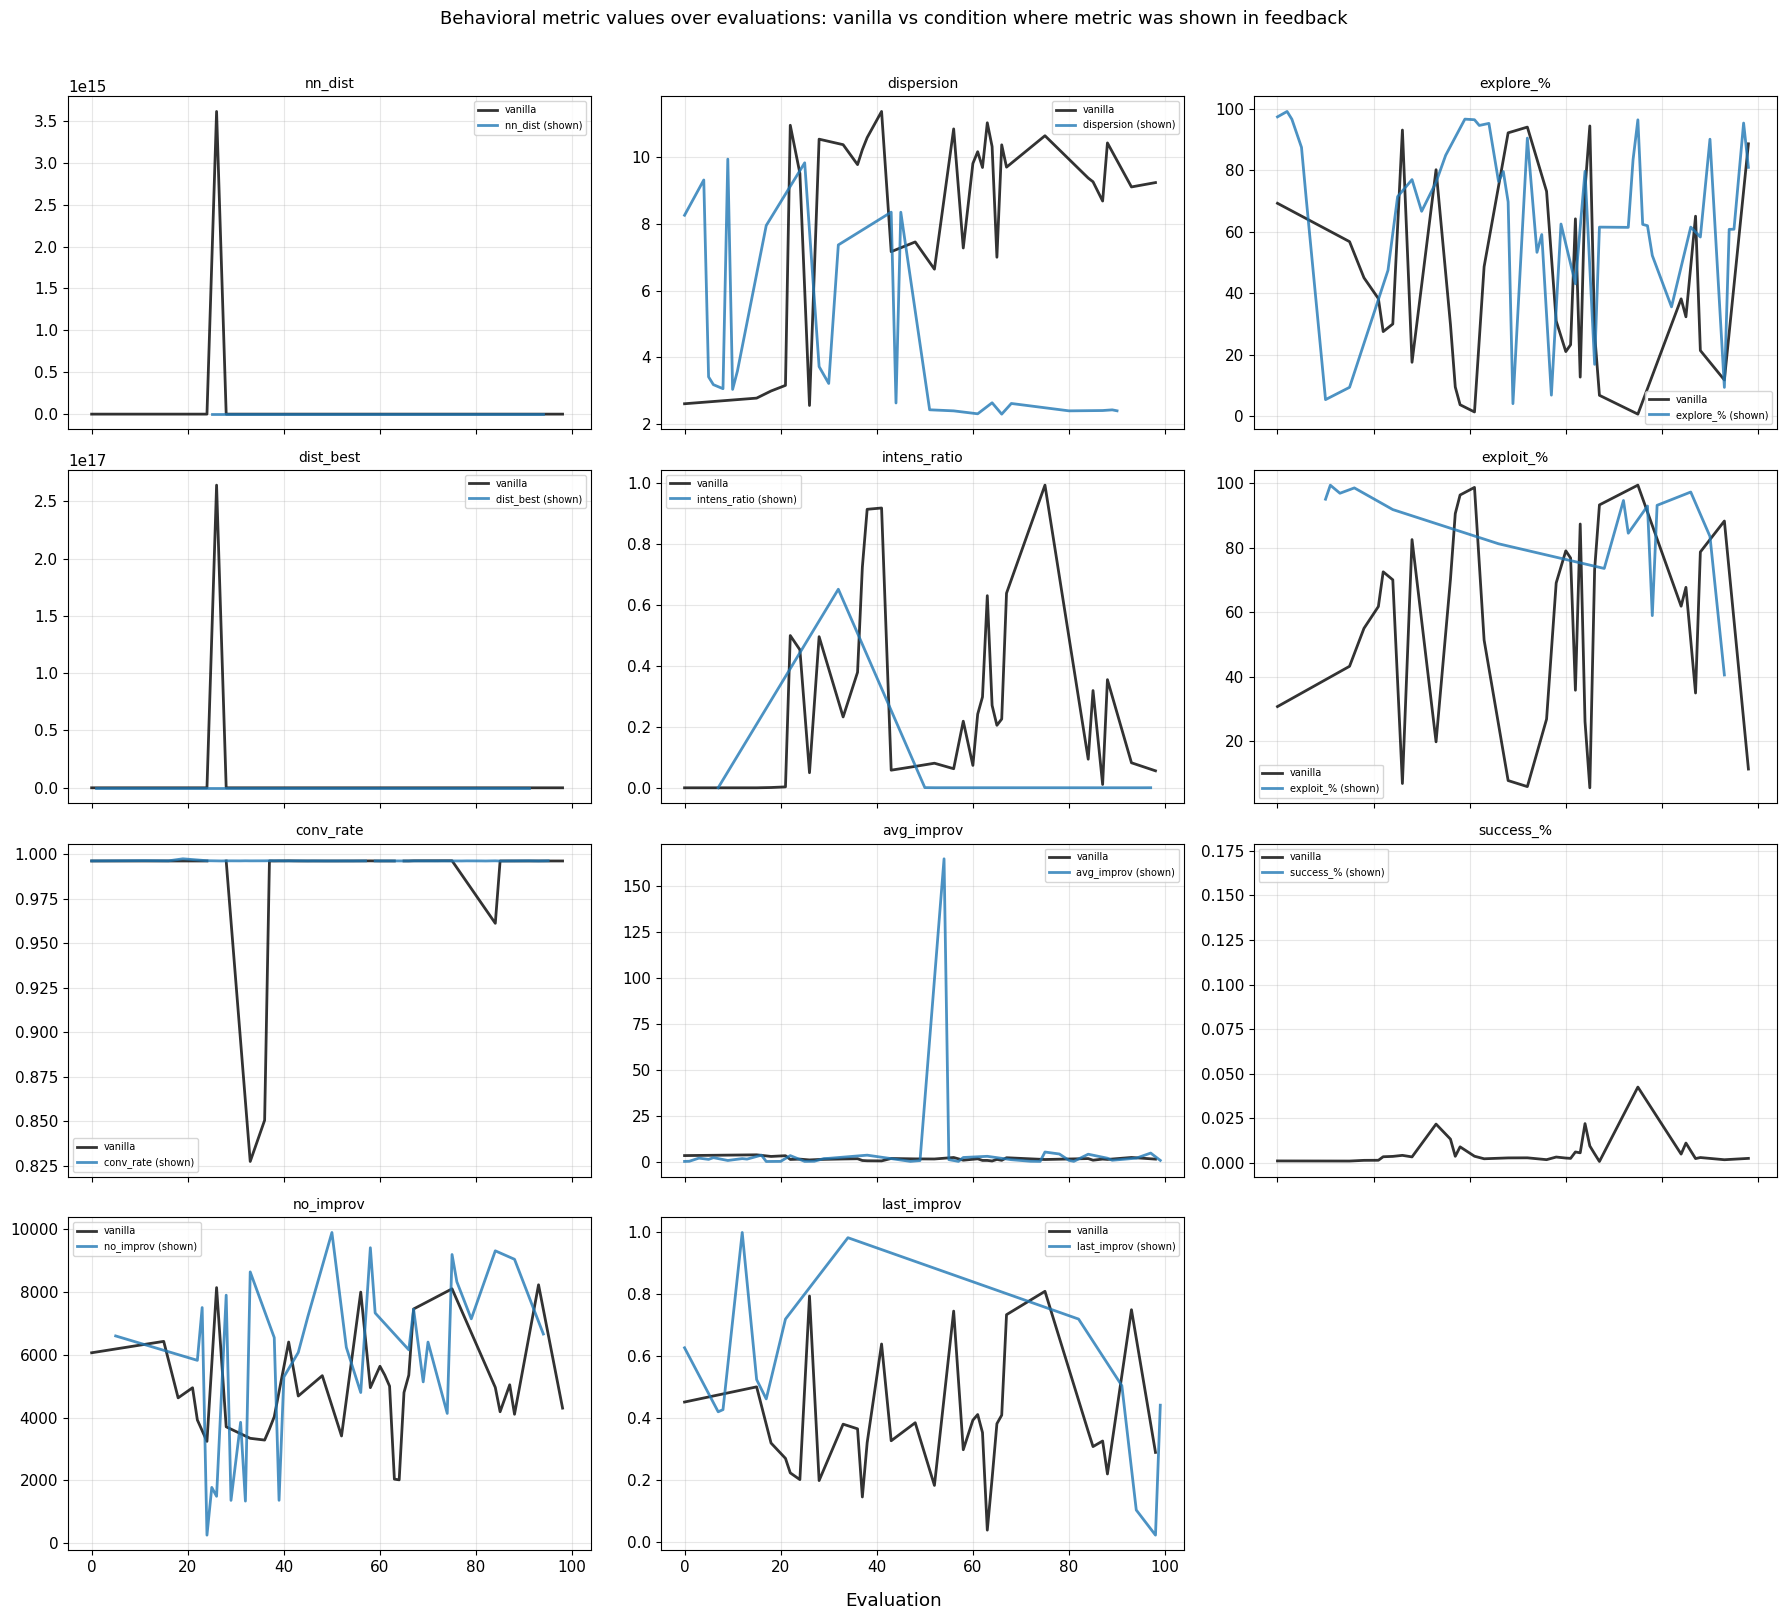

In [14]:
# How does each behavioral metric evolve over the 100 evaluations?
# Focus: does showing a metric in feedback change how it develops?

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True)

for idx, feat in enumerate(ALL_FEATURES):
    ax = axes[idx // 3, idx % 3]
    
    # Plot the metric for vanilla and for the condition where it was shown
    for cond, color, lw, label in [
        ("vanilla", "black", 2, "vanilla"),
        (feat, "tab:blue", 2, f"{SHORT_NAMES[feat]} (shown)"),
    ]:
        subset = df_valid[df_valid["condition"] == cond].sort_values("evaluation")
        if feat in subset.columns and subset[feat].notna().any():
            ax.plot(subset["evaluation"], subset[feat],
                    color=color, linewidth=lw, label=label, alpha=0.8)
    
    ax.set_title(SHORT_NAMES[feat], fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Remove empty subplot if odd number
if len(ALL_FEATURES) % 3 != 0:
    for i in range(len(ALL_FEATURES) % 3, 3):
        axes[-1, i].set_visible(False)

fig.supxlabel("Evaluation")
fig.suptitle("Behavioral metric values over evaluations: vanilla vs condition where metric was shown in feedback",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_99774/3780374526.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bsf_metric = subset[feat].where(is_new_best).ffill()
/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_99774/3780374526.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bsf_metric = subset[feat].where(is_new_best).ffill()
/var/folders/jr/n9z3k78146x3z51srj3w4g3c0000gn/T/ipykernel_99774/3780374526.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futu

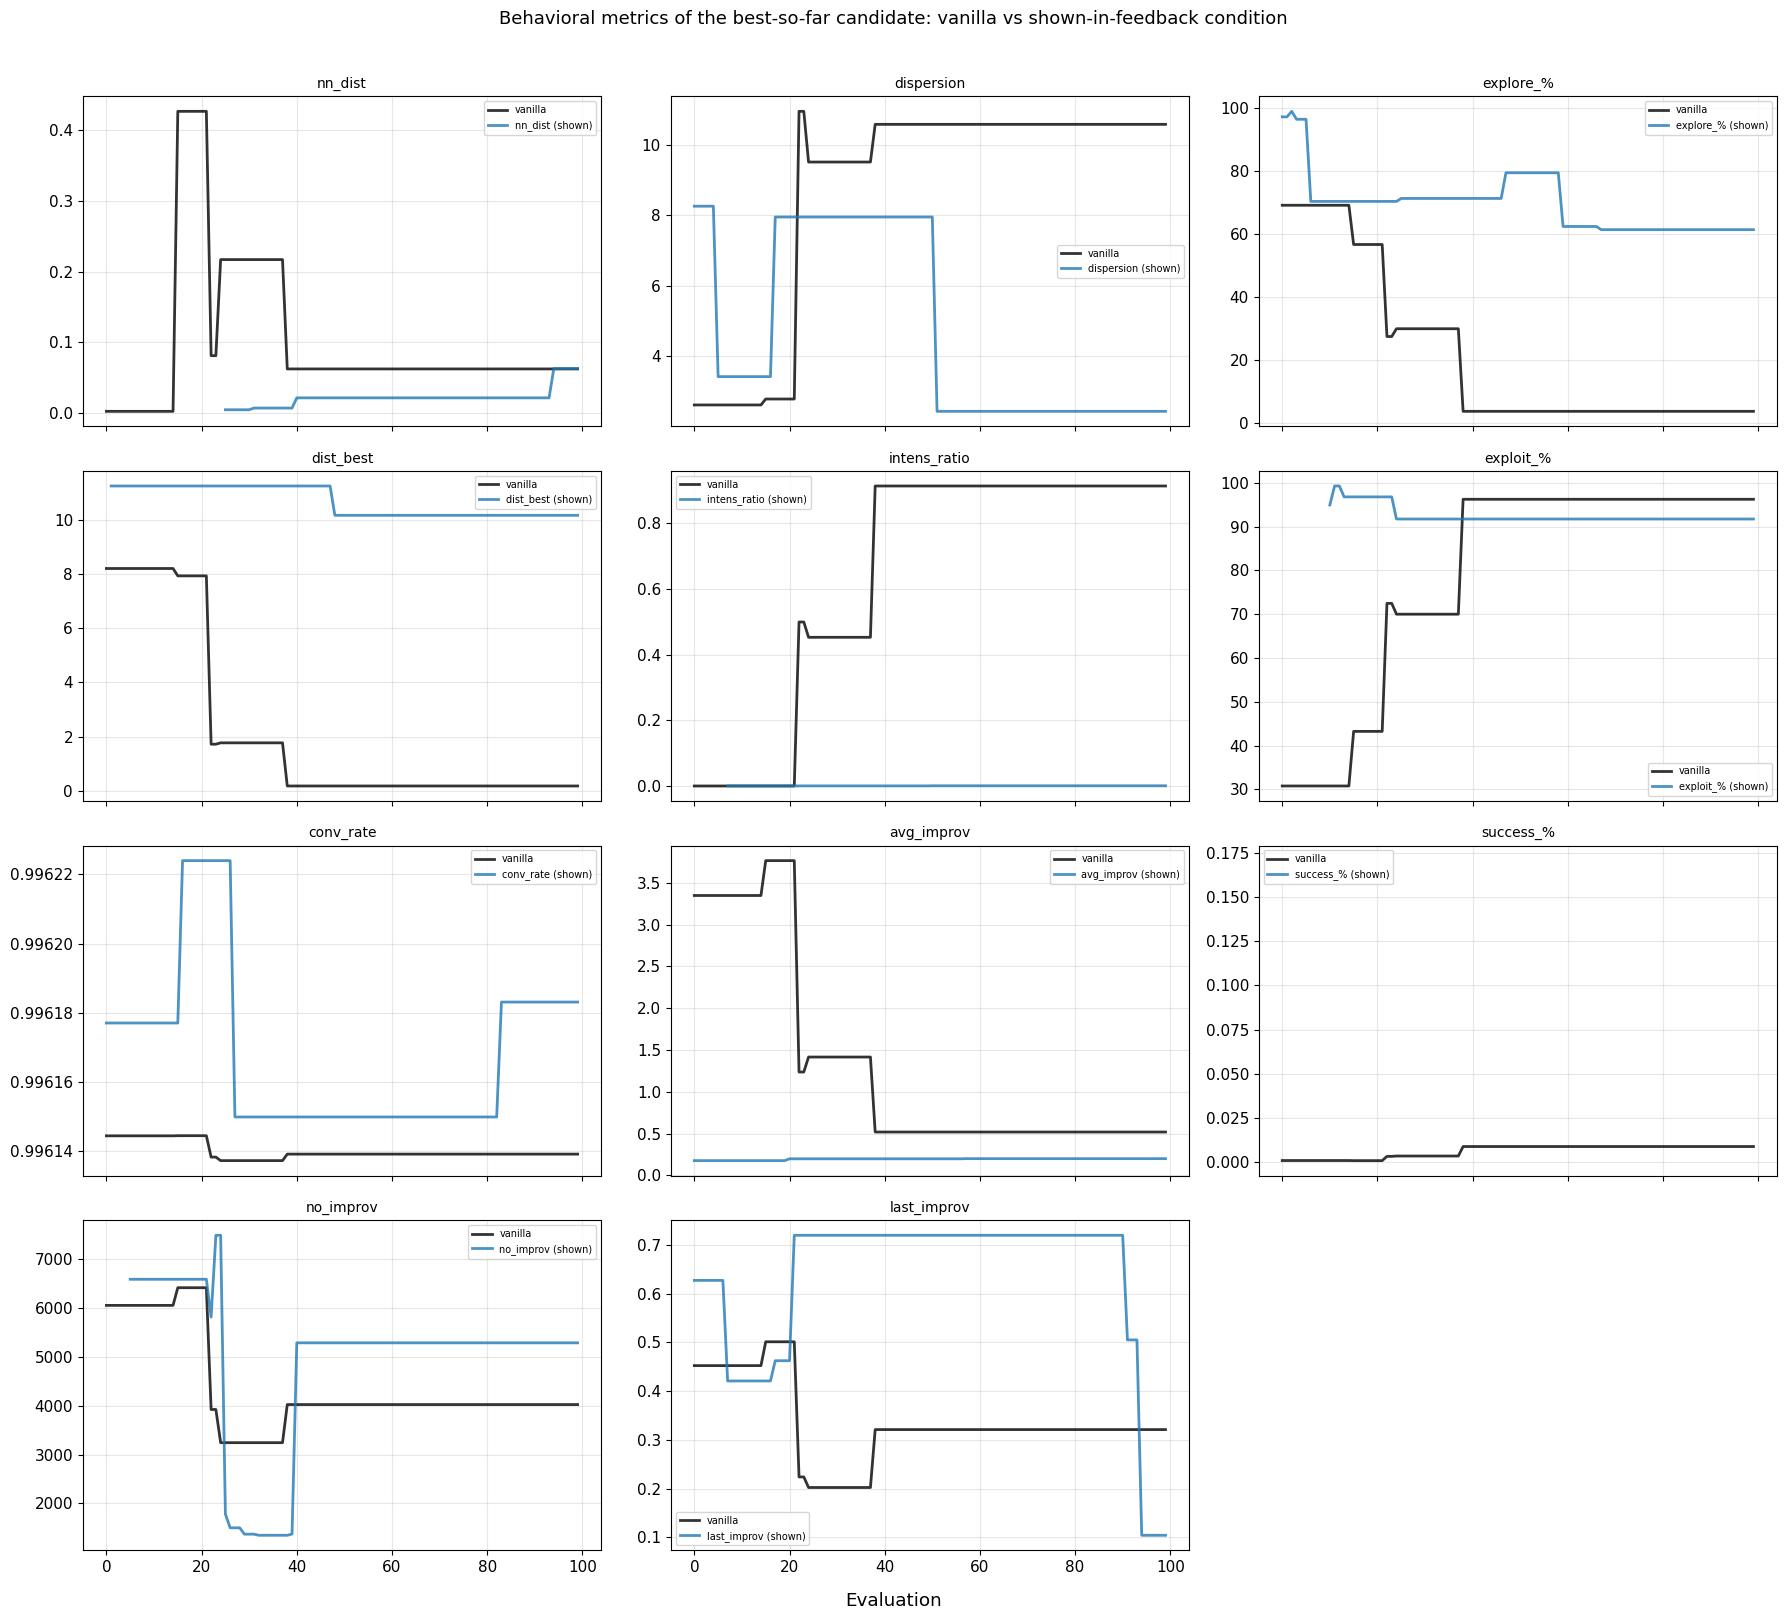

In [15]:
# Best-so-far version: track the behavioral metrics of the best candidate so far
fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True)

for idx, feat in enumerate(ALL_FEATURES):
    ax = axes[idx // 3, idx % 3]
    
    for cond, color, lw, label in [
        ("vanilla", "black", 2, "vanilla"),
        (feat, "tab:blue", 2, f"{SHORT_NAMES[feat]} (shown)"),
    ]:
        subset = df[df["condition"] == cond].sort_values("evaluation").copy()
        # Only consider valid candidates for "is new best"
        valid_mask = ~subset["failed"]
        # Track best-so-far fitness (cummax handles -inf correctly)
        cummax = subset["fitness"].cummax()
        is_new_best = valid_mask & (subset["fitness"] >= cummax)
        
        if feat in subset.columns:
            bsf_metric = subset[feat].where(is_new_best).ffill()
            # Only plot from first valid candidate onwards
            first_valid = valid_mask.idxmax() if valid_mask.any() else None
            if first_valid is not None:
                plot_slice = subset.loc[first_valid:]
                metric_slice = bsf_metric.loc[first_valid:]
                ax.plot(plot_slice["evaluation"], metric_slice,
                        color=color, linewidth=lw, label=label, alpha=0.8)
    
    ax.set_title(SHORT_NAMES[feat], fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

if len(ALL_FEATURES) % 3 != 0:
    for i in range(len(ALL_FEATURES) % 3, 3):
        axes[-1, i].set_visible(False)

fig.supxlabel("Evaluation")
fig.suptitle("Behavioral metrics of the best-so-far candidate: vanilla vs shown-in-feedback condition",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

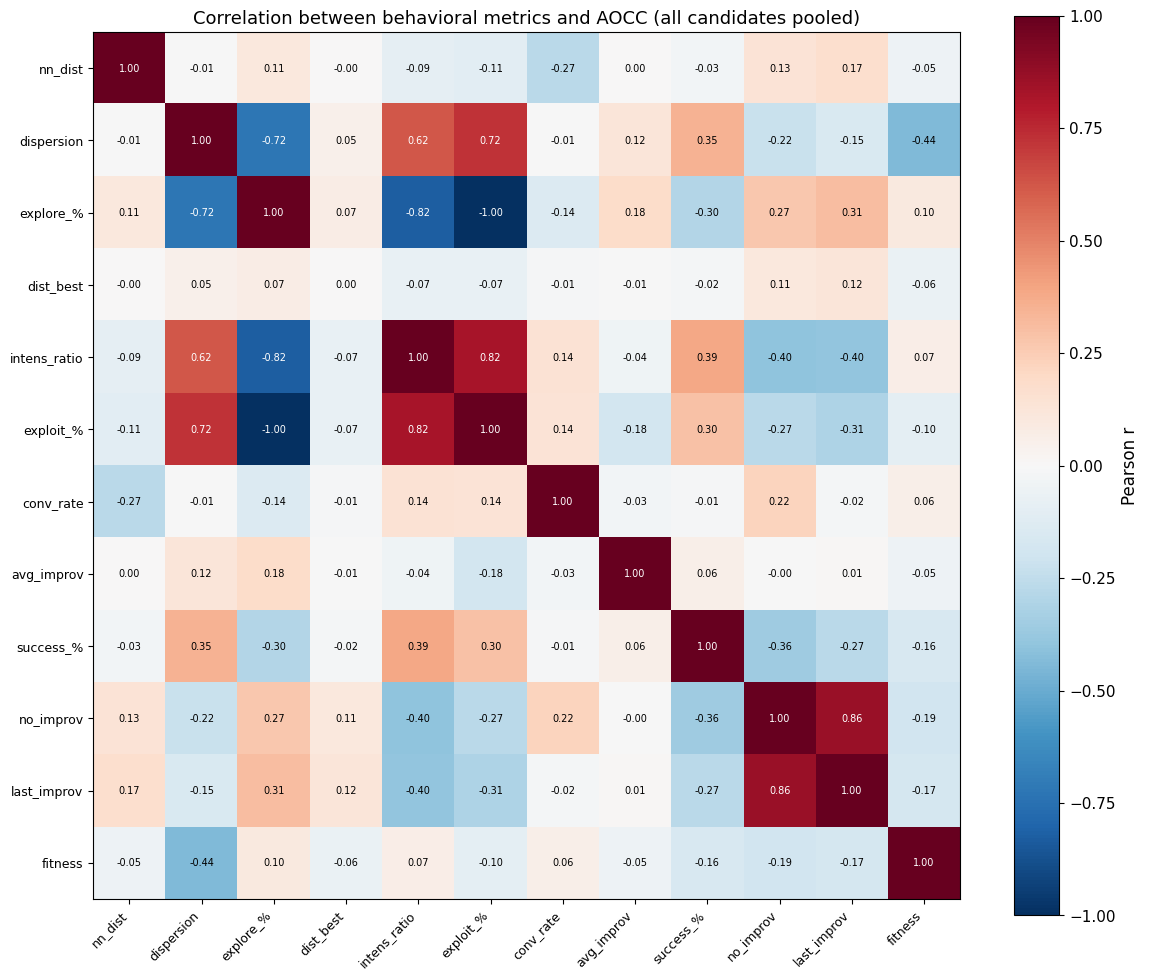


Correlation with AOCC (fitness):
avg_exploration_pct              0.0954
intensification_ratio            0.0677
average_convergence_rate         0.0561
avg_improvement                 -0.0488
avg_nearest_neighbor_distance   -0.0537
avg_distance_to_best            -0.0642
avg_exploitation_pct            -0.0954
success_rate                    -0.1604
last_improvement_fraction       -0.1747
longest_no_improvement_streak   -0.1880
dispersion                      -0.4386


In [16]:
# Pearson correlation between all metrics and AOCC, pooled across all conditions
corr_cols = ALL_FEATURES + ["fitness"]
corr_data = df_valid[corr_cols].dropna()

corr_matrix = corr_data.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

labels = [SHORT_NAMES.get(c, c) for c in corr_cols]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(val) > 0.5 else "black")

fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation between behavioral metrics and AOCC (all candidates pooled)")
plt.tight_layout()
plt.show()

# Print fitness correlations specifically
print("\nCorrelation with AOCC (fitness):")
fitness_corr = corr_matrix["fitness"].drop("fitness").sort_values(ascending=False)
print(fitness_corr.to_string(float_format="{:.4f}".format))

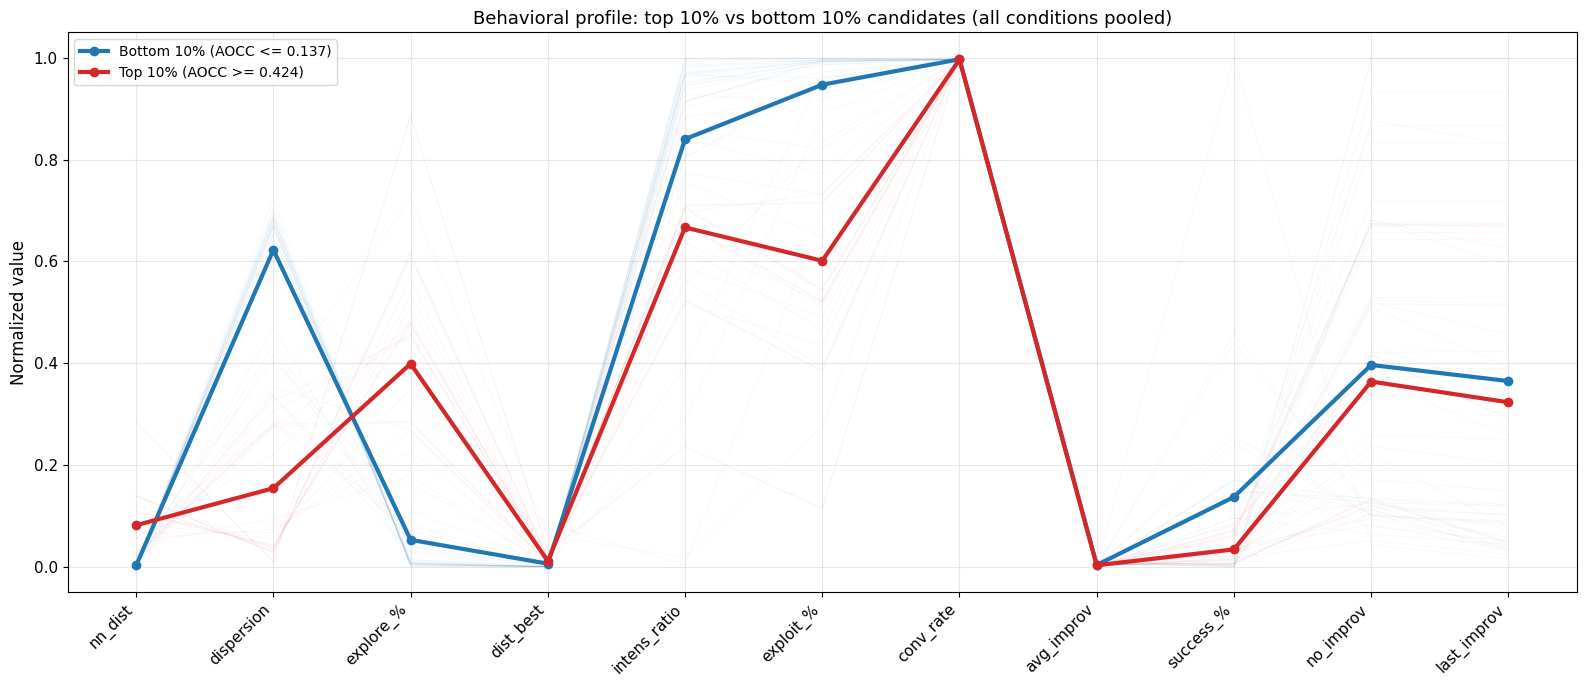

In [22]:
# Parallel coordinate plot: behavior profile of top vs bottom candidates
from sklearn.preprocessing import MinMaxScaler

# Use all valid candidates across all conditions
feat_data = df_valid[ALL_FEATURES + ["fitness"]].copy()

# Coerce all feature columns to numeric (handles mixed types from JSON)
for col in ALL_FEATURES:
    feat_data[col] = pd.to_numeric(feat_data[col], errors="coerce")

# Drop rows with NaN or infinite values
feat_data = feat_data.replace([np.inf, -np.inf], np.nan).dropna()

if len(feat_data) < 10:
    print(f"Only {len(feat_data)} candidates with complete behavioral data — skipping parallel coordinates plot")
else:
    scaler = MinMaxScaler()
    feat_norm = pd.DataFrame(
        scaler.fit_transform(feat_data[ALL_FEATURES]),
        columns=ALL_FEATURES,
        index=feat_data.index,
    )
    feat_norm["fitness"] = feat_data["fitness"].values

    q90 = feat_norm["fitness"].quantile(0.90)
    q10 = feat_norm["fitness"].quantile(0.10)
    top = feat_norm[feat_norm["fitness"] >= q90]
    bottom = feat_norm[feat_norm["fitness"] <= q10]

    fig, ax = plt.subplots(figsize=(16, 7))

    for _, row in bottom.iterrows():
        ax.plot(range(len(ALL_FEATURES)), row[ALL_FEATURES].values,
                color="tab:blue", alpha=0.05, linewidth=0.5)
    for _, row in top.iterrows():
        ax.plot(range(len(ALL_FEATURES)), row[ALL_FEATURES].values,
                color="tab:red", alpha=0.05, linewidth=0.5)

    ax.plot(range(len(ALL_FEATURES)), bottom[ALL_FEATURES].mean().values,
            color="tab:blue", linewidth=3, label=f"Bottom 10% (AOCC <= {q10:.3f})", marker="o")
    ax.plot(range(len(ALL_FEATURES)), top[ALL_FEATURES].mean().values,
            color="tab:red", linewidth=3, label=f"Top 10% (AOCC >= {q90:.3f})", marker="o")

    ax.set_xticks(range(len(ALL_FEATURES)))
    ax.set_xticklabels([SHORT_NAMES[f] for f in ALL_FEATURES], rotation=45, ha="right")
    ax.set_ylabel("Normalized value")
    ax.set_title("Behavioral profile: top 10% vs bottom 10% candidates (all conditions pooled)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Summary

In [18]:
# Comprehensive summary table
summary_rows = []
for cond in CONDITIONS:
    cond_data = df[df["condition"] == cond]
    valid_data = df_valid[df_valid["condition"] == cond]
    
    row = {
        "condition": SHORT_NAMES[cond],
        "final_best_aocc": cond_data["best_so_far"].iloc[-1] if len(cond_data) else np.nan,
        "mean_candidate_aocc": valid_data["fitness"].mean() if len(valid_data) else np.nan,
        "median_candidate_aocc": valid_data["fitness"].median() if len(valid_data) else np.nan,
        "n_valid": len(valid_data),
        "n_failed": len(cond_data) - len(valid_data),
        "failure_rate_%": (len(cond_data) - len(valid_data)) / len(cond_data) * 100 if len(cond_data) else 0,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("condition")
summary_df = summary_df.sort_values("final_best_aocc", ascending=False)

print("Comprehensive Summary")
print("=" * 100)
print(summary_df.to_string(float_format="{:.4f}".format))

# Note about failure rates
print("\nNote: High failure rates are expected — the LLM generates candidate algorithms")
print("that may contain syntax errors, runtime errors, or produce invalid results.")
print("The (1+1)-ES simply retains the best valid candidate found so far.")

Comprehensive Summary
              final_best_aocc  mean_candidate_aocc  median_candidate_aocc  n_valid  n_failed  failure_rate_%
condition                                                                                                   
avg_improv             0.7052               0.3360                 0.3084       37        63         63.0000
exploit_%              0.6604               0.3762                 0.3170       15        85         85.0000
no_improv              0.5809               0.2643                 0.2480       32        68         68.0000
last_improv            0.5178               0.2555                 0.2430       13        87         87.0000
dispersion             0.4762               0.2975                 0.2767       26        74         74.0000
explore_%              0.4290               0.3021                 0.3019       45        55         55.0000
vanilla                0.4160               0.2418                 0.2508       33        67         67.00